<a href="https://colab.research.google.com/github/neelimareddyb/Traffic-sign-recognition/blob/main/Copy_of_alp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

# 2. Download the Dataset
# We check if data exists first to avoid re-downloading if you run it twice
if not os.path.exists('data'):
    print("Downloading dataset... Please wait.")
    !mkdir -p data
    !wget -P data -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip

    print("Unzipping dataset...")
    !unzip -q data/GTSRB_Final_Training_Images.zip -d data
    print("Dataset extraction successful!")
else:
    print("Dataset already exists. Skipping download.")

Unzipping dataset...
Dataset extraction successful!


In [ ]:
# Settings
data = []
labels = []
classes = 43 # We use all 43 classes for the full dataset
cur_path = os.getcwd()

# Path to the downloaded images
base_dir = os.path.join(cur_path, 'data/GTSRB/Final_Training/Images')

print("Loading and resizing images...")

# Loop through all 43 folders (0 to 42)
for i in range(classes):
    path = os.path.join(base_dir, f'{i:05d}')
    images = os.listdir(path)

    for a in images:
        # CRITICAL FIX: Skip the CSV configuration files
        if a.endswith(".csv"):
            continue

        try:
            # 1. Open Image
            image = Image.open(path + '/'+ a)
            # 2. Resize to 30x30 pixels
            image = image.resize((30,30))
            # 3. Convert to Number Array (Numpy)
            image = np.array(image)

            data.append(image)
            labels.append(i)
        except Exception as e:
            print(f"Error loading image: {e}")

# Convert lists to efficient Numpy arrays
data = np.array(data)
labels = np.array(labels)


print("Success! Images are loaded and resized.")
print(f"Total Images: {data.shape[0]}")
print(f"Image Dimensions: {data.shape[1]}x{data.shape[2]}")

# ... (your existing loop that loads images) ...

# Convert lists to numpy arrays
data = np.array(data)
labels = np.array(labels)

print("Normalizing data (0-255 -> 0-1)...")
data = data.astype('float32') / 255.0


print(f"Data shape: {data.shape}")

Loading and resizing images...
Success! Images are loaded and resized.
Total Images: 39209
Image Dimensions: 30x30
Normalizing data (0-255 -> 0-1)...
Data shape: (39209, 30, 30, 3)


In [ ]:
print("Step 3: Splitting data into 70% Train, 15% Val, 15% Test...")

# 1. First Split: Separate Training (70%) from the rest (30%)
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)

# 2. Second Split: Split the remaining 30% equally (50/50) into Validation and Test
# (Half of 30% is 15%, which is exactly what we want)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 3. One-Hot Encoding
# This changes the label "5" into "[0, 0, 0, 0, 0, 1, 0...]"
y_train = to_categorical(y_train, classes)
y_val = to_categorical(y_val, classes)
y_test = to_categorical(y_test, classes)

print("-----------------------------------------")
print(f"Training Data (70%):   {X_train.shape[0]} images")
print(f"Validation Data (15%): {X_val.shape[0]} images")
print(f"Testing Data (15%):    {X_test.shape[0]} images")
print("-----------------------------------------")
print("Data splitting and encoding complete.")

Step 3: Splitting data into 70% Train, 15% Val, 15% Test...
-----------------------------------------
Training Data (70%):   27446 images
Validation Data (15%): 5881 images
Testing Data (15%):    5882 images
-----------------------------------------
Data splitting and encoding complete.


In [ ]:
print("Step 4: Building the CNN Model...")

model = Sequential()

# --- Layer 1: Feature Extraction ---
# 32 Filters, 5x5 Kernel, ReLU activation
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# --- Layer 2: Deep Feature Extraction ---
# 64 Filters (finding more complex shapes), 3x3 Kernel
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# --- Layer 3: Classification ---
model.add(Flatten()) # Flatten 2D images to 1D vector
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))

# Output Layer: 43 neurons (one for each traffic sign)
model.add(Dense(classes, activation='softmax'))

# Compile the model
# We use 'categorical_crossentropy' because we have multiple classes (43)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("-----------------------------------------")
print("Model created successfully!")
model.summary()

Step 4: Building the CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


-----------------------------------------
Model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,251 (946.29 KB)

 Trainable params: 242,251 (946.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Step 5: Training the model...")

# Epochs: How many times the model sees the entire dataset
epochs = 15
batch_size = 128

history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_val, y_val))

print("-----------------------------------------")
print("Training complete!")

Step 5: Training the model...
Epoch 1/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.2421 - loss: 2.8871 - val_accuracy: 0.9012 - val_loss: 0.3607
Epoch 2/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8368 - loss: 0.5450 - val_accuracy: 0.9708 - val_loss: 0.1106
Epoch 3/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9213 - loss: 0.2593 - val_accuracy: 0.9815 - val_loss: 0.0657
Epoch 4/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9523 - loss: 0.1675 - val_accuracy: 0.9878 - val_loss: 0.0494
Epoch 5/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9631 - loss: 0.1236 - val_accuracy: 0.9889 - val_loss: 0.0392
Epoch 6/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9675 - loss: 0.1038 - val_accuracy: 0.9903 - val_loss: 0.0330
Epoch 7/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9740 - loss: 0.0873 - val_accuracy: 0.9932 - val_loss: 0.0267
Epoch 8/15
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9775 

Step 6: Generating accuracy and loss graphs...


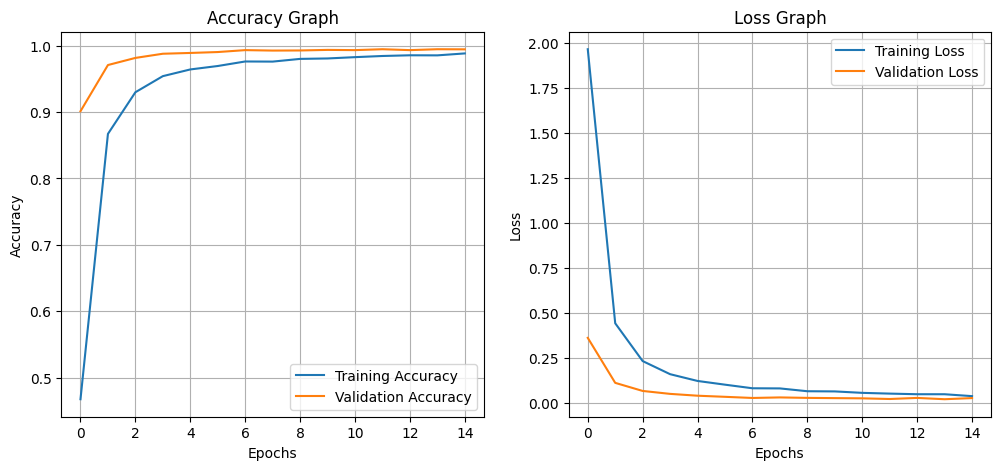

-----------------------------------------
Graphs generated successfully.


In [ ]:
print("Step 6: Generating accuracy and loss graphs...")

plt.figure(figsize=(12, 5))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

print("-----------------------------------------")
print("Graphs generated successfully.")

In [ ]:
print("Step 7: Evaluating on the Test Set (The hidden 15%)...")

# evaluate() returns [loss, accuracy]
score = model.evaluate(X_test, y_test, verbose=0)

print("-----------------------------------------")
print(f"Test Loss:     {score[0]:.4f}")
print(f"Test Accuracy: {score[1]*100:.2f}%")
print("-----------------------------------------")

if score[1] > 0.95:
    print("RESULT: Excellent! The model is highly accurate.")
else:
    print("RESULT: Good, but could be improved.")

Step 7: Evaluating on the Test Set (The hidden 15%)...
-----------------------------------------
Test Loss:     0.0259
Test Accuracy: 99.42%
-----------------------------------------
RESULT: Excellent! The model is highly accurate.


In [ ]:
print("Step 8: Saving the model...")

# 1. Save the model to a single file (H5 format)
model_filename = "traffic_sign_model.h5"
model.save(model_filename)

print(f"Success! Model saved as '{model_filename}'.")

# 2. Check if the file actually exists
if os.path.exists(model_filename):
    print(f"File size: {os.path.getsize(model_filename) / 1000000:.2f} MB")
    print("You can now download this file from the 'Files' tab on the left.")
else:
    print("Error: File not found.")

Step 8: Saving the model...
Success! Model saved as 'traffic_sign_model.h5'.
File size: 2.97 MB
You can now download this file from the 'Files' tab on the left.


In [ ]:
# Dictionary to map Class IDs to actual names
classes_dict = {
    0:'Speed limit (20km/h)',
    1:'Speed limit (30km/h)',
    2:'Speed limit (50km/h)',
    3:'Speed limit (60km/h)',
    4:'Speed limit (70km/h)',
    5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)',
    7:'Speed limit (100km/h)',
    8:'Speed limit (120km/h)',
    9:'No passing',
    10:'No passing veh over 3.5 tons',
    11:'Right-of-way at intersection',
    12:'Priority road',
    13:'Yield',
    14:'Stop',
    15:'No vehicles',
    16:'Veh > 3.5 tons prohibited',
    17:'No entry',
    18:'General caution',
    19:'Dangerous curve left',
    20:'Dangerous curve right',
    21:'Double curve',
    22:'Bumpy road',
    23:'Slippery road',
    24:'Road narrows on the right',
    25:'Road work',
    26:'Traffic signals',
    27:'Pedestrians',
    28:'Children crossing',
    29:'Bicycles crossing',
    30:'Beware of ice/snow',
    31:'Wild animals crossing',
    32:'End speed + passing limits',
    33:'Turn right ahead',
    34:'Turn left ahead',
    35:'Ahead only',
    36:'Go straight or right',
    37:'Go straight or left',
    38:'Keep right',
    39:'Keep left',
    40:'Roundabout mandatory',
    41:'End of no passing',
    42:'End no passing veh > 3.5 tons'
}

print("Dictionary loaded")

Dictionary loaded


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


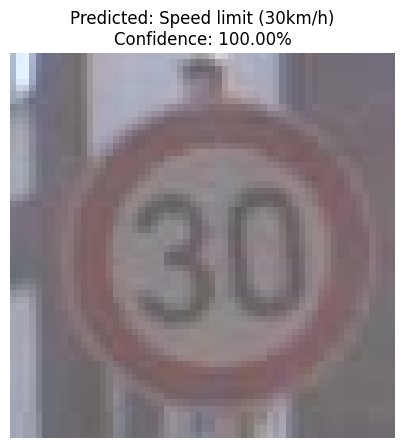

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os


image_filename = "traffic5.jpeg"  # <--- Change this to match your uploaded file


def predict_uploaded_image(filename):
    # Check if file exists first
    if not os.path.exists(filename):
        print(f"Error: The file '{filename}' was not found.")
        print("Make sure you uploaded it to the Files tab on the left.")
        return

    try:
        # Load image
        img = Image.open(filename)

        # Resize to 30x30 (Model requirement)
        img_resized = img.resize((30, 30))

        # Convert to array
        img_array = np.array(img_resized)

        # Handle PNGs with transparency (4 channels) -> Convert to RGB (3 channels)
        if img_array.shape[-1] == 4:
            img_array = img_array[..., :3]

        # Add batch dimension (1, 30, 30, 3)
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        pred = model.predict(img_array)
        class_index = np.argmax(pred)
        confidence = np.max(pred)

        # Get the name from the dictionary
        # (Make sure you ran the cell with 'classes_dict' previously!)
        sign_name = classes_dict[class_index]

        # Display
        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {sign_name}\nConfidence: {confidence*100:.2f}%")
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Run the function
predict_uploaded_image(image_filename)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


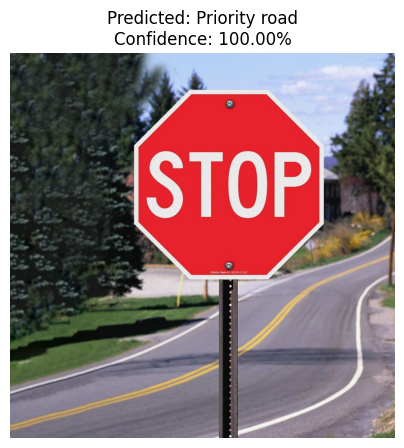

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os


image_filename = "TRAFFIC.jpeg"  # <--- Change this to match your uploaded file


def predict_uploaded_image(filename):
    # Check if file exists first
    if not os.path.exists(filename):
        print(f"Error: The file '{filename}' was not found.")
        print("Make sure you uploaded it to the Files tab on the left.")
        return

    try:
        # Load image
        img = Image.open(filename)

        # Resize to 30x30 (Model requirement)
        img_resized = img.resize((30, 30))

        # Convert to array
        img_array = np.array(img_resized)

        # Handle PNGs with transparency (4 channels) -> Convert to RGB (3 channels)
        if img_array.shape[-1] == 4:
            img_array = img_array[..., :3]

        # Add batch dimension (1, 30, 30, 3)
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        pred = model.predict(img_array)
        class_index = np.argmax(pred)
        confidence = np.max(pred)

        # Get the name from the dictionary
        # (Make sure you ran the cell with 'classes_dict' previously!)
        sign_name = classes_dict[class_index]

        # Display
        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {sign_name}\nConfidence: {confidence*100:.2f}%")
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Run the function
predict_uploaded_image(image_filename)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


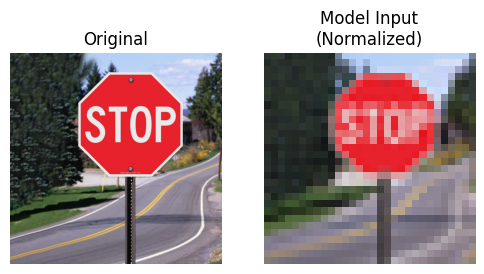

Prediction: Priority road
Confidence: 32.80%


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- SETTINGS ---
filename = "TRAFFIC.jpeg"  # Your uploaded file
# ----------------

def predict_smart(image_path):
    try:
        img = Image.open(image_path)

        # 1. SMART CROP: Cut a square from the center (Don't squish!)
        width, height = img.size
        new_size = min(width, height)

        left = (width - new_size) / 2
        top = (height - new_size) / 2
        right = (width + new_size) / 2
        bottom = (height + new_size) / 2

        img_cropped = img.crop((left, top, right, bottom))

        # 2. Resize to 30x30
        img_resized = img_cropped.resize((30, 30))
        img_array = np.array(img_resized)

        # 3. Fix Channels
        if img_array.shape[-1] == 4:
            img_array = img_array[..., :3]

        # 4. CRITICAL FIX: NORMALIZE (Divide by 255)
        # Only do this if you divided your training data by 255.
        # If you aren't sure, try it with and without this line.
        img_array = img_array.astype('float32') / 255.0

        # 5. Predict
        img_batch = np.expand_dims(img_array, axis=0)
        prediction = model.predict(img_batch)

        class_index = np.argmax(prediction)
        confidence = np.max(prediction)
        result_name = classes_dict[class_index]

        # Display
        plt.figure(figsize=(6,3))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(img_resized)
        plt.title(f"Model Input\n(Normalized)")
        plt.axis('off')
        plt.show()

        print(f"Prediction: {result_name}")
        print(f"Confidence: {confidence*100:.2f}%")

    except Exception as e:
        print(f"Error: {e}")

predict_smart(filename)